# (Case Study 2)
## Report on : Analysis of US Births Dataset (2000–2014)

Name: Rehmat Tadpatri

USN: 2BL22CI066

Course: Data Analysis using Python

## Problem Statement

This case study analyzes the US Births dataset (2000–2014) obtained from the Social Security Administration (SSA). The objective is to investigate patterns in daily birth counts across different days of the week and throughout the year.The goal is to identify statistical trends, variability, and distribution characteristics in birth data while handling irregular observations.

# Data Cleaning

# 2a) Read in US_births_2000-2014_SSA.csv

In [2]:
#to import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#read the dataset into a dataframe in pandas
df = pd.read_csv("US_births_2000-2014_SSA.csv")
#top rows of the data table
df.head()

,year,month,date_of_month,day_of_week,births,date
0,2000,1,1.0,6,9083.0,01-01-2000
1,2000,1,2.0,7,8006.0,01-02-2000
2,2000,1,3.0,1,11363.0,01-03-2000
3,2000,1,4.0,2,13032.0,01-04-2000
4,2000,1,5.0,3,12558.0,01-05-2000


In [3]:
# to check dataset information
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5479 entries, 0 to 5478
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           5479 non-null   int64  
 1   month          5479 non-null   int64  
 2   date_of_month  5478 non-null   float64
 3   day_of_week    5479 non-null   int64  
 4   births         5465 non-null   float64
 5   date           5479 non-null   object 
dtypes: float64(2), int64(3), object(1)
memory usage: 257.0+ KB


,year,month,date_of_month,day_of_week,births
count,5479.000000,5479.000000,5478.000000,5479.000000,5465.000000
mean,2006.999270,6.522723,15.727455,3.999817,11348.814456
std,4.321085,3.449075,8.799535,2.000502,2327.445105
min,2000.000000,1.000000,1.000000,1.000000,5728.000000
25%,2003.000000,4.000000,8.000000,2.000000,8739.000000
50%,2007.000000,7.000000,16.000000,4.000000,12343.000000
75%,2011.000000,10.000000,23.000000,6.000000,13083.000000
max,2014.000000,12.000000,31.000000,7.000000,16081.000000


In [4]:
# Check data types
df.dtypes

year               int64
month              int64
date_of_month    float64
day_of_week        int64
births           float64
date              object
dtype: object

In [5]:
# Summary statistics
df.describe()

,year,month,date_of_month,day_of_week,births
count,5479.000000,5479.000000,5478.000000,5479.000000,5465.000000
mean,2006.999270,6.522723,15.727455,3.999817,11348.814456
std,4.321085,3.449075,8.799535,2.000502,2327.445105
min,2000.000000,1.000000,1.000000,1.000000,5728.000000
25%,2003.000000,4.000000,8.000000,2.000000,8739.000000
50%,2007.000000,7.000000,16.000000,4.000000,12343.000000
75%,2011.000000,10.000000,23.000000,6.000000,13083.000000
max,2014.000000,12.000000,31.000000,7.000000,16081.000000


In [6]:
# Check missing values
df.isnull().sum()

year              0
month             0
date_of_month     1
day_of_week       0
births           14
date              0
dtype: int64

In [7]:
# Check duplicate rows
df.duplicated().sum()

np.int64(0)

# 2b) Remove all the rows corresponding to holidays

In [11]:
#Remove all the rows corresponding to holidays
holidays = [(1,1),(7,4),(12,25)]

df = df[~df[['month','date_of_month']].apply(tuple,axis=1).isin(holidays)]

df.head()

,year,month,date_of_month,day_of_week,births,date
2,2000,1,3.0,1,11363.0,01-03-2000
3,2000,1,4.0,2,13032.0,01-04-2000
4,2000,1,5.0,3,12558.0,01-05-2000
6,2000,1,7.0,5,12516.0,01-07-2000
9,2000,1,10.0,1,11668.0,01-10-2000


# 2c) Remove all the rows on weekdays that are less than 10,000

In [12]:
#Remove all the rows on weekdays that are less than 10,000
df = df[df["births"] >= 10000]
print(df)


      year  month  date_of_month  day_of_week   births        date
2     2000      1            3.0            1  11363.0  01-03-2000
3     2000      1            4.0            2  13032.0  01-04-2000
4     2000      1            5.0            3  12558.0  01-05-2000
6     2000      1            7.0            5  12516.0  01-07-2000
9     2000      1           10.0            1  11668.0  01-10-2000
...    ...    ...            ...          ...      ...         ...
5470  2014     12           23.0            2  12604.0  12/23/2014
5473  2014     12           26.0            5  10386.0  12/26/2014
5476  2014     12           29.0            1  12811.0  12/29/2014
5477  2014     12           30.0            2  13634.0  12/30/2014
5478  2014     12            NaN            3  11990.0  12/31/2014

[3790 rows x 6 columns]


# 2d) What is the average number of births per day for each day of the week?

In [13]:
avg_births = df.groupby('day_of_week')['births'].mean()

print("Average Births Per Weekday:")
print(avg_births)

Average Births Per Weekday:
day_of_week
1    12145.919837
2    13191.042857
3    12967.827497
4    13009.237086
5    12708.005284
6    10499.000000
Name: births, dtype: float64


# 2e) What is the median number of births per day for each day of the week?

In [14]:
median_births = df.groupby('day_of_week')['births'].median()

print("Median Births Per Weekday:")
print(median_births)

Median Births Per Weekday:
day_of_week
1    12141.5
2    13206.0
3    12949.0
4    12985.0
5    12667.0
6    10499.0
Name: births, dtype: float64


# 2f) How dispersed are the number of births per day for each day of the week?

In [15]:
dispersion = df.groupby('day_of_week')['births'].std()

print("Standard Deviation (Dispersion):")
print(dispersion)

Standard Deviation (Dispersion):
day_of_week
1    628.929305
2    685.675857
3    736.101952
4    723.970982
5    750.823985
6           NaN
Name: births, dtype: float64


# 2g) What is the interquartile range (IQR) of the number of births per day for each day of the week?

In [16]:
Q1 = df.groupby('day_of_week')['births'].quantile(0.25)
Q3 = df.groupby('day_of_week')['births'].quantile(0.75)

IQR = Q3 - Q1

print("Interquartile Range:")
print(IQR)

Interquartile Range:
day_of_week
1    863.50
2    883.25
3    936.00
4    947.00
5    947.00
6      0.00
Name: births, dtype: float64


# 2h) Find the outliers for the number of births per day for each day of the week using the IQR method

In [17]:
Q1 = df['births'].quantile(0.25)
Q3 = df['births'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['births'] < lower_bound) | (df['births'] > upper_bound)]

print("Outliers:")
print(outliers)

Outliers:
      year  month  date_of_month  day_of_week   births        date
51    2000      2           21.0            1  10610.0   2/21/2000
360   2000     12           26.0            2  10395.0  12/26/2000
367   2001      1            2.0            2  10635.0  01-02-2001
415   2001      2           19.0            1  10522.0   2/19/2001
730   2001     12           31.0            1  10272.0  12/31/2001
821   2002      4            1.0            1  10264.0  04-01-2002
1143  2003      2           17.0            1  10707.0   2/17/2003
1455  2003     12           26.0            5  10431.0  12/26/2003
1462  2004      1            2.0            5  10586.0  01-02-2004
1826  2004     12           31.0            5  10130.0  12/31/2004
2130  2005     10           31.0            1  10207.0  10/31/2005
2183  2005     12           23.0            5  10642.0  12/23/2005
2378  2006      7            6.0            4  15007.0  07-06-2006
2440  2006      9            6.0            3  15391

# Data Visualization

# 2i) Produce box and whisker plots for the number of births per day for each day of the week

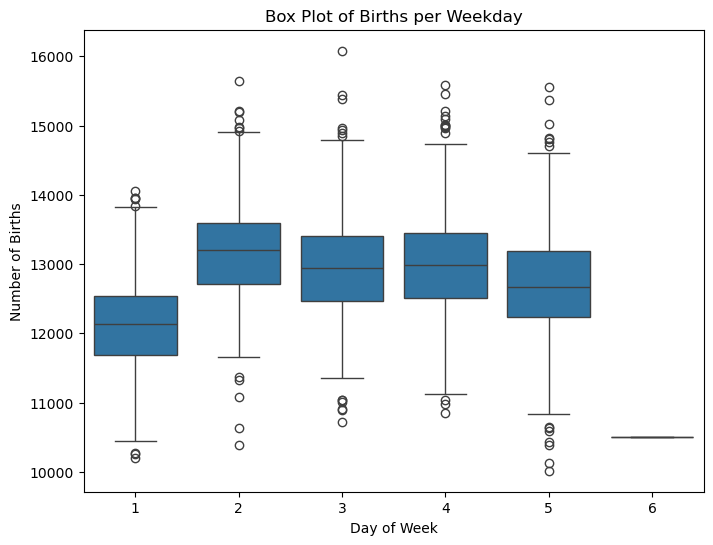

In [18]:
plt.figure(figsize=(8,6))

sns.boxplot(x='day_of_week', y='births', data=df)

plt.title("Box Plot of Births per Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Number of Births")

plt.show()

The box plot shows the distribution of the number of births for each day of the week. It helps to compare how birth counts vary across different days. From the plot, we can observe that births are generally higher on some weekdays, while a few outliers indicate unusually high or low birth counts.

# 2j) Produce histograms and KDE plots for the number of births per day for each day of the week

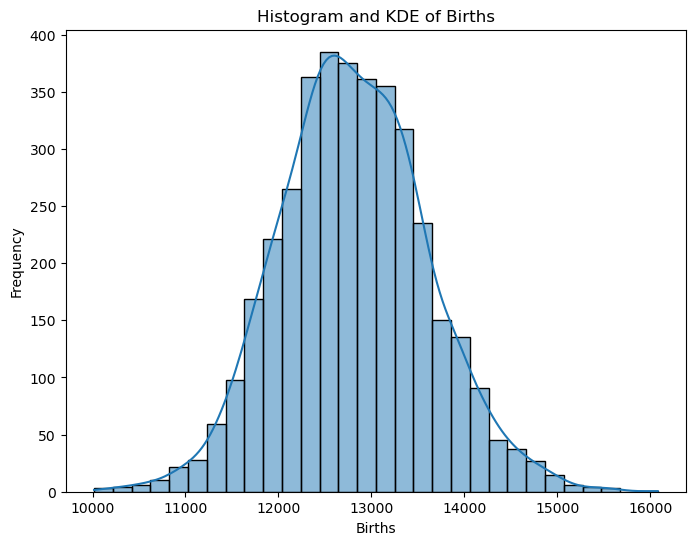

In [19]:
plt.figure(figsize=(8,6))

sns.histplot(df['births'], bins=30, kde=True)

plt.title("Histogram and KDE of Births")
plt.xlabel("Births")
plt.ylabel("Frequency")

plt.show()

The histogram and KDE plot show the distribution of daily birth counts. Most birth values are concentrated around 12000–13000, forming a bell-shaped pattern, which indicates that the data follows an approximately normal distribution.

# 2k) Find by what day of the year 50% of births have occurred for each year

In [21]:
# create date column
df["date"] = pd.to_datetime({
    "year": df["year"],
    "month": df["month"],
    "day": df["date_of_month"]
})

# find day of year
df["day_of_year"] = df["date"].dt.dayofyear

# cumulative births per year
births_cumsum = df.groupby(["year","day_of_year"])["births"].sum().groupby(level=0).cumsum()

# total births per year
total_births = df.groupby("year")["births"].sum()

# proportion of births
result = births_cumsum / total_births

# day when 50% births occurred
day_50 = result[result >= 0.5].groupby("year").idxmin()

print(day_50)

year
2000    (2000, 189.0)
2001    (2001, 184.0)
2002    (2002, 184.0)
2003    (2003, 184.0)
2004    (2004, 188.0)
2005    (2005, 186.0)
2006    (2006, 187.0)
2007    (2007, 184.0)
2008    (2008, 183.0)
2009    (2009, 183.0)
2010    (2010, 183.0)
2011    (2011, 186.0)
2012    (2012, 187.0)
2013    (2013, 186.0)
2014    (2014, 184.0)
Name: births, dtype: object


# 2l) In 2000, between what days of the year do 50% of births occur

In [22]:
# filter data for year 2000
df2000 = df[df["year"] == 2000]

# cumulative births by day of year
cum_births = df2000.groupby("day_of_year")["births"].sum().cumsum()

# total births in 2000
total = cum_births.iloc[-1]

# find 25% and 75% points
start = cum_births[cum_births >= total * 0.25].index[0]
end = cum_births[cum_births >= total * 0.75].index[0]

print(start, end)

95.0 273.0
